# Tutorial

This tutorial provides a step-by-step guide to analyzing rotational diffusion of molecules from molecular dynamics simulations using the `rotationaldiffusion` package. Please check out our paper and the documentation to get all details.

## Introduction

Rotational diffusion describes how molecules reorient in solution. For rigid bodies, this diffusion process is described by a rotational diffusion tensor, which can be characterized using its principal components (eigenvalues) $D_x$, $D_y$, and $D_z$ along the principal axes of the molecule.

In this tutorial, we'll:
1. Extract the orientations of a molecule over time
2. Compute the covariance matrix / rotational correlation functions
3. Fit a rotational diffusion model
4. Determine the associated uncertainties

## Setup

First, let's import the necessary packages:

In [1]:
# We don't need to see warnings in this Tutorial.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysisTests.datafiles import PSF, DCD
import RotationalDiffusion as rd

# Set up matplotlib for better visualization
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams['font.size'] = 12

## Calculating Orientations

The first step in analyzing rotational diffusion is to calculate the orientations of the molecule at each time point. The `rotationaldiffusion` package provides the `Orientations` analysis class for this purpose. Here, we are exploring this class using a short trajectory from `MDAnalysisTests`.

In [2]:
warnings.filterwarnings("ignore") 

# Load trajectory
u = mda.Universe(PSF, DCD)

# Select the atoms for analysis.
selection = "name CA or name C or name N" # Protein backbone

# Initialize the orientation analysis.
orient_analysis = rd.orientations.Orientations(u, select=selection, unwrap=False)

# Run the analysis.
orient_analysis.run()

# Get the resulting orientations (rotation matrices).
orientations = orient_analysis.results.orientations
print(f"Calculated {len(orientations)} orientation matrices of shape {orientations[0].shape}")

Calculated 98 orientation matrices of shape (3, 3)


**Note:** By default, molecules will be unwrapped and centered. This behaviour can be overwritten by setting `unwrap=False` and `center=False`, to speed up computations in case the provided trajectories are already unwrapped and centered. Also, the `Orientations` class supports parallelization using `multiprocessing` or `dask`, which can be enabled by passing the `backend` and `n_workers` flags to the `.run()` method.

## Computing the covariance matrix / rotational correlation functions.

Next, we'll compute a covariance matrix containing six rotational correlation functions, which describe how the orientation decorrelates over time. We are switching to orientations pre-computed from ten MD simulations of Ubiquitin, lasting $1 \mu s$ each.

In [3]:
# Load data.
orientations = np.load('data/orientations.npy')

# Compute the covariance matrix Q by correlating the orientations.
correlations = rd.correlate(orientations)
print(f"Computed correlation matrix Q with shape {correlations.shape}")

# Average over all 10 simulations.
correlations_av = np.mean(correlations, axis=0)

# Get corresponding lag times.
timestep = 0.1  # ns
lag_times = np.arange(1, len(correlations_av)+1) * timestep
print(f"Lag times range from {lag_times[0]} to {lag_times[-1]} ns")

Computed correlation matrix Q with shape (10, 1000, 3, 3)
Lag times range from 0.1 to 100.0 ns


## Visualizing Correlations

Let's visualize the rotational correlation functions to understand how the orientations decorrelate over time.

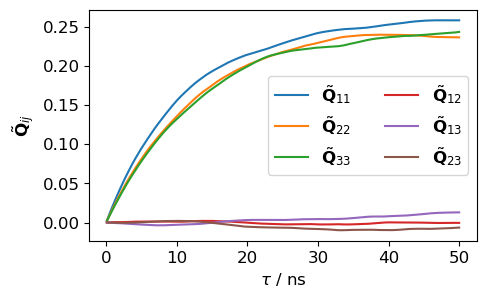

In [4]:
# Create a plot for visualizing Q matrix components
fig, ax = plt.subplots()

# Set axis labels.
ax.set_xlabel('$\\tau$ / ns')
ax.set_ylabel(r'$\bf{\~{Q}}$'+"$_{{{i}{j}}}$")

# Some helper variables.
_ndx_fin = 500
_corr = np.moveaxis(correlations_av, 0, -1)

# Plot the diagonal correlation functions.
for i in range(3):
    ax.plot(lag_times[:_ndx_fin], _corr[i, i, :_ndx_fin], label=r'$\bf{\tilde{Q}}$'+f"$_{{{i+1}{i+1}}}$")

# Plot the off-diagonal correlation functions.
for i in range(3):
    j, k = max(i, 1) - 1, min(i, 1) + 1
    ax.plot(lag_times[:_ndx_fin], _corr[j, k, :_ndx_fin], label=r'$\bf{\tilde{Q}}$'+f"$_{{{j+1}{k+1}}}$")
    
ax.legend(ncol=2)

The results look exactly as expected. The diagonal correlation functions begin at zero, rise, and converge to values close to 0.25. In contrast, the off-diagonal correlation functions remain close to zero. These features should be checked when analyzing rotational diffusion from MD.

## Time-Dependent Diffusion Coefficients and principal axes

We can compute the desired diffusion coefficients and principal axes as functions of correlation time directly from the correlation functions from before. These time-dependent quantities provide valuable diagnostic information. To analyze the time-dependent principal axes, we convert them to time dependent *principal angles*, e.g.
$$
    \alpha_x (\tau) = \vec x (\tau) \cdot \vec x (\tau_{ref.}),
$$
where $\tau_{ref.}$ is a fixed reference time.

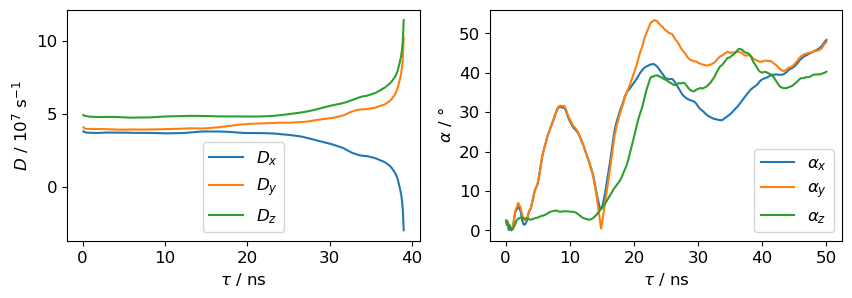

In [5]:
# Calculate time-dependent diffusion coefficients and principal axes
D_time_dep, PAF_time_dep = rd.instantaneous_tensors(lag_times, correlations_av)

# Plot time-dependent diffusion coefficients
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

# Set labels.
axs[0].set_xlabel('$\\tau$ / ns')
axs[0].set_ylabel('$D$ / $10^{7}$ s$^{-1}$')
axs[1].set_xlabel('$\\tau$ / ns')
axs[1].set_ylabel('$\\alpha$ / °')

_ndx_ini = 0
_ndx_fin = 500
for i, axis in enumerate('xyz'):
    axs[0].plot(lag_times[_ndx_ini:_ndx_fin], D_time_dep[_ndx_ini:_ndx_fin, ..., i] * 1e2, label=f"$D_{axis}$", c=f"C{i}")

    # Convert principal axes to principal angles, using tau_ref = 1 ns.
    cos = np.abs(np.dot(PAF_time_dep[:, i], PAF_time_dep[9, i]))
    angle = np.rad2deg(np.arccos(cos))
    axs[1].plot(lag_times[_ndx_ini:_ndx_fin], angle[_ndx_ini:_ndx_fin], label=f"$\\alpha_{axis}$", c=f"C{i}")

axs[0].legend(loc='lower center')
axs[1].legend(loc='lower right')

Constant regions in the graphs of the time-dependent diffusion coefficients indicate converged, Browninan behavior. Here, this is roughly the region until 15 ns. This region will be used for fitting in the next step. Also the $z$-angle is stable in that regime, whereas the $x$- and $y$-angles are highly non-constant, indicating semi-isotropic behaviour. This is also evident from the diffusion plots, which show $D_x\approx D_y$.

## Fitting a diffusion model

Three models are available for fitting:
- `anisotropic`: Full anisotropic diffusion with three independent coefficients (D₁, D₂, D₃)
- `semi-isotropic`: Axially symmetric diffusion (D∥, D⊥)
- `isotropic`: Isotropic diffusion with a single coefficient (D)

In all cases three principal axes are fitted, but they lack a physical meaning in case of semi-isotropic ($x$- and $y$-axes) or isotropic (all axes) rotational diffusion. 

Despite the clear indication for semi-isotropic diffusion, we will continue with the fully anisotropic model.

In [6]:
# Fit an anisotropic diffusion model
_ndx_fin = 150 # Limit the fit window to 15 ns, as discussed above. 
fit_aniso = rd.least_squares_fit(lag_times[:_ndx_fin], correlations_av[:_ndx_fin], model='anisotropic')
D_fitted = fit_aniso.D * 1e9 # Convert to per seconds.

print(f"Anisotropic diffusion coefficients: {D_fitted[0] / 1e7:.2f}, {D_fitted[1] / 1e7:.2f}, {D_fitted[2] / 1e7:.2f} x 10^7 s^-1")

Anisotropic diffusion coefficients: 3.72, 3.96, 4.81 x 10^7 s^-1


This is almost the final result. It still needs to be corrected to acknowledge the finite size effect and the viscosity of the water model. 

## Estimating uncertainties
*This section will follow soon.*